In [4]:
import pandas as pd

vle = pd.read_csv("studentVle.csv")

# Keep only useful columns
vle_small = vle[["id_student", "sum_click"]]

# Aggregate immediately (this shrinks it A LOT)
vle_small = vle_small.groupby("id_student").sum().reset_index()

# Save smaller file
vle_small.to_csv("studentVle_small.csv", index=False)

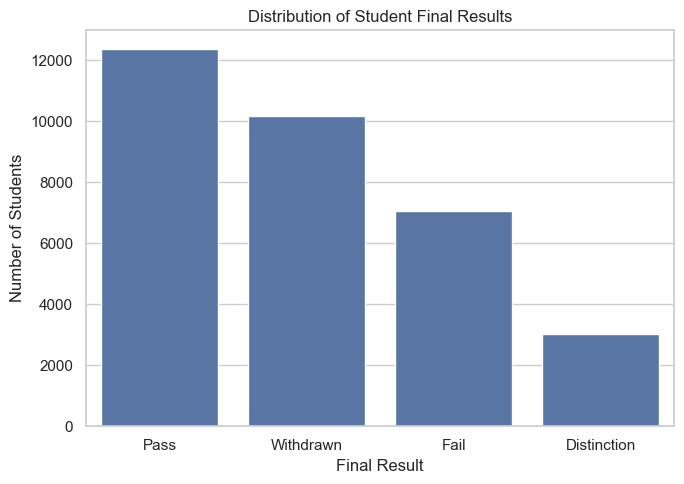

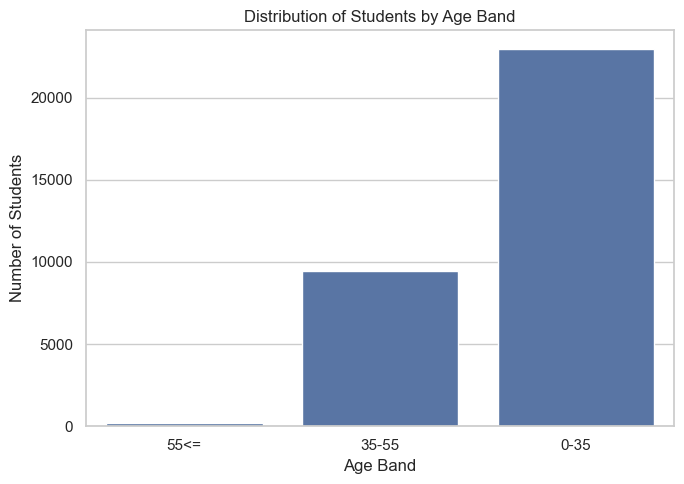

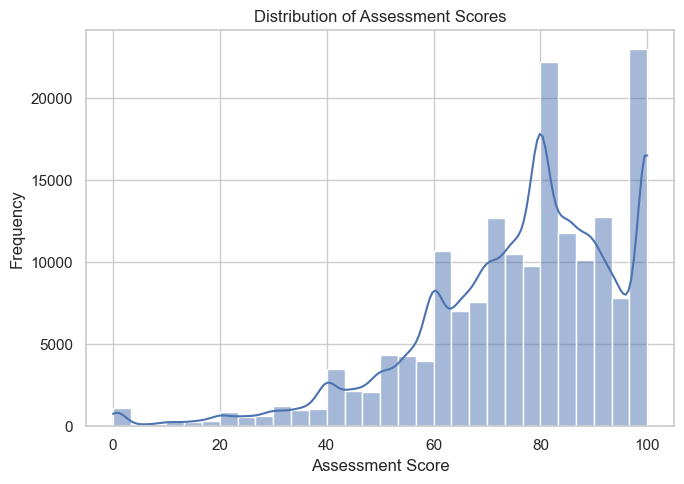

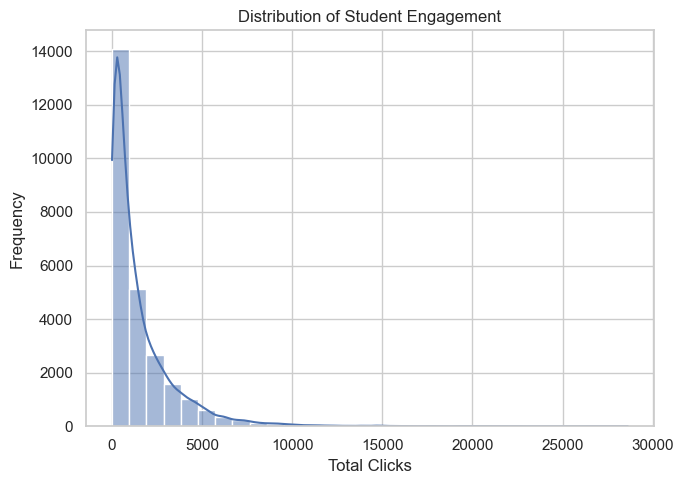

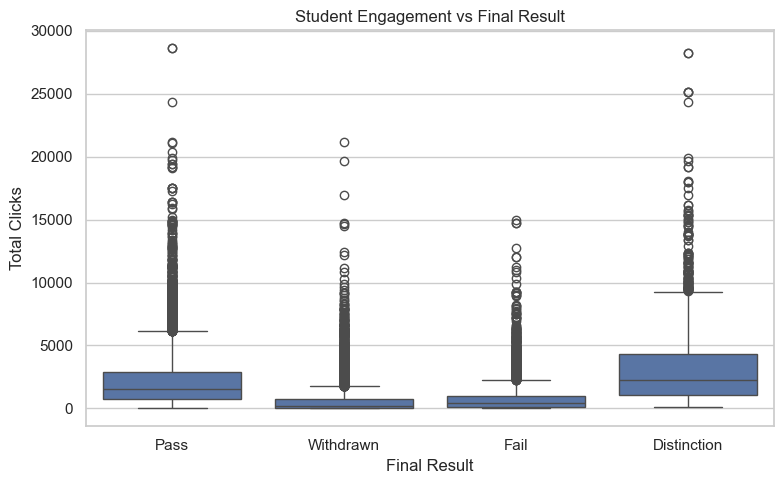

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

student_info = pd.read_csv("studentInfo.csv")
student_assessment = pd.read_csv("studentAssessment.csv")
student_vle = pd.read_csv("studentVle_small.csv")

# 1. Final result distribution
plt.figure(figsize=(7, 5))
sns.countplot(x="final_result", data=student_info)
plt.title("Distribution of Student Final Results")
plt.xlabel("Final Result")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.savefig("final_result_distribution.png", dpi=300)
plt.show()


# 2. Age distribution
plt.figure(figsize=(7, 5))
sns.countplot(x="age_band", data=student_info)
plt.title("Distribution of Students by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.savefig("age_distribution.png", dpi=300)
plt.show()


# 3. Assessment score distribution
plt.figure(figsize=(7, 5))
sns.histplot(student_assessment["score"].dropna(), bins=30, kde=True)
plt.title("Distribution of Assessment Scores")
plt.xlabel("Assessment Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("score_distribution.png", dpi=300)
plt.show()


# 4. Engagement distribution
plt.figure(figsize=(7, 5))
sns.histplot(student_vle["sum_click"].dropna(), bins=30, kde=True)
plt.title("Distribution of Student Engagement")
plt.xlabel("Total Clicks")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("engagement_distribution.png", dpi=300)
plt.show()


# 5. Engagement vs final result
merged = student_info.merge(student_vle, on="id_student", how="left")
merged["sum_click"] = merged["sum_click"].fillna(0)

plt.figure(figsize=(8, 5))
sns.boxplot(x="final_result", y="sum_click", data=merged)
plt.title("Student Engagement vs Final Result")
plt.xlabel("Final Result")
plt.ylabel("Total Clicks")
plt.tight_layout()
plt.savefig("engagement_vs_result.png", dpi=300)
plt.show()